<a href="https://colab.research.google.com/github/jamesnd04/RAGNotebook/blob/main/Supabase_Message_Log_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## **Supabase Message Log Notebook**

This notebook demonstrates how to connect to a [Supabase](https://supabase.com/) database and query message logs from a specific table. The goal is to retrieve, format, and display these logs in a human-readable format using Python and visualization libraries.

We'll cover:
- Connecting securely to Supabase
- Querying message logs
- Displaying logs in a clean, readable format




# **Step 0: Installing Prerequisites**

In [ ]:
!pip install pandas
!pip install supabase
!pip install data_table

# **Step One: Connect to Supabase**

## ❓ What is Supabase?

[Supabase]() is an open-source backend-as-a-service platform that provides a suite of tools for building and scaling applications. It offers a PostgreSQL database, authentication, real-time subscriptions, and storage—all accessible through a simple API.

In this notebook, Supabase is used to store and manage message logs from our chatbots. Each time a user interacts with a chatbot, the conversation is logged in a Supabase table. This allows us to retrieve, analyze, and visualize those messages for debugging, analytics, or training purposes.

First, we will connect to Supabase in this cell. To start, upload your secret keys using Google Secrets to the left. You will need a Supabase URL and Key, which can be found in under Project Settings -> Data API.


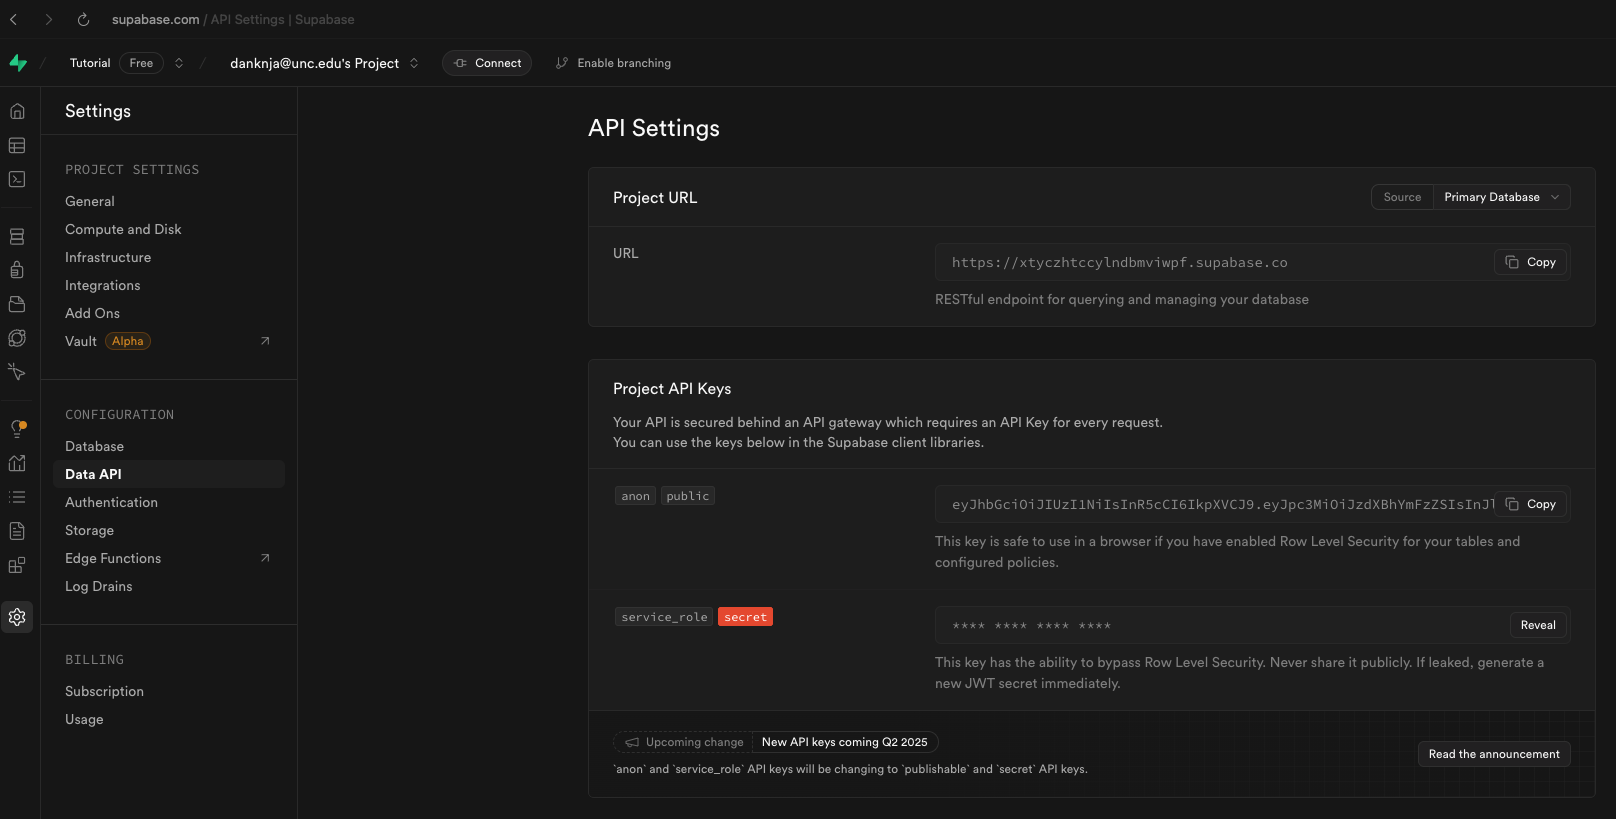

In [ ]:

from google.colab import userdata

from supabase import create_client, Client
import os


SUPABASE_URL = userdata.get('SUPABASE_URL')
SUPABASE_KEY = userdata.get('SUPABASE_API_KEY')

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

# **Step Two: Retrieve Messages**


## ⚠️ Make Sure You Have Read Permissions

Before querying data from your Supabase table, ensure that your API key has the appropriate **read permissions** for the table you're accessing.

If read access is not properly configured, your query will fail or return an empty result.

You can manage these settings in the **Supabase Dashboard** under:
- **Table Editor → [Your Table] → Policies**

Be cautious with open policies in production environments—only allow access where appropriate.


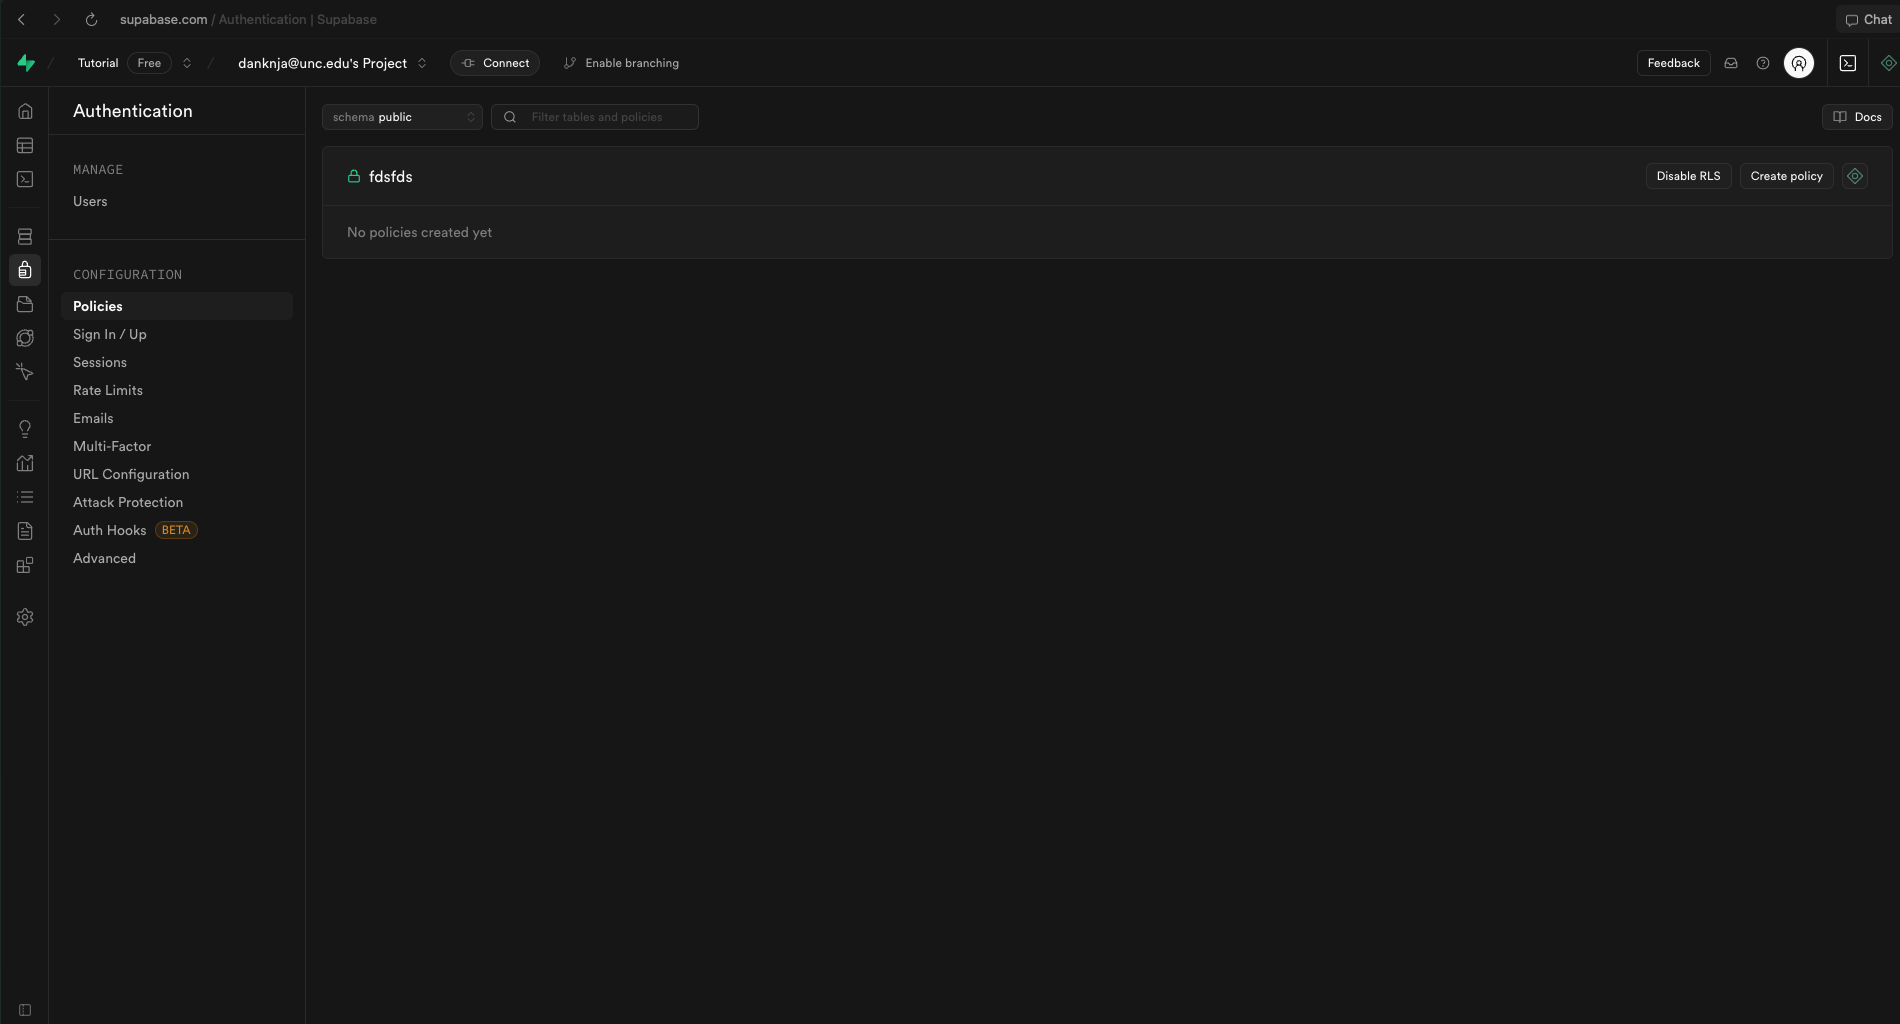

Then you can create and edit policies to ensure your Notebook can actually read your tables.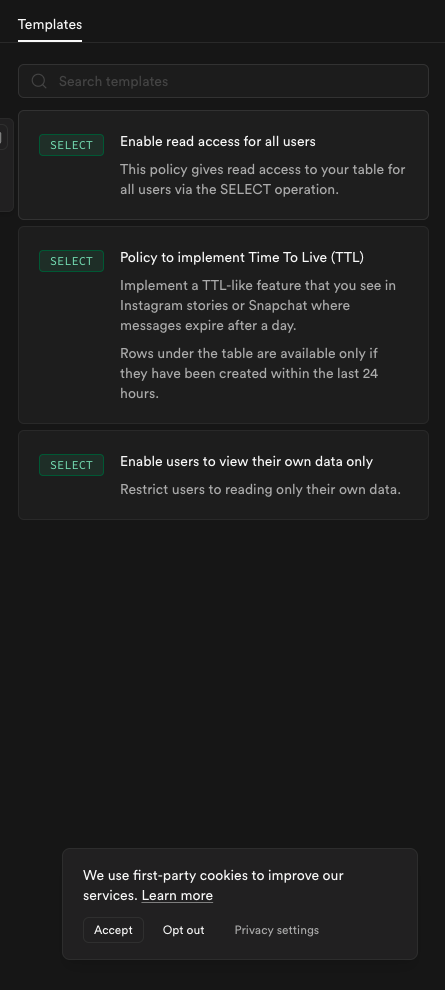

## Retrieving Data from Supabase Tables

Once connected to Supabase, we can query data from any table in our database using the Supabase Python client. In this notebook, we’re specifically interested in retrieving message logs stored in a table (e.g., `user_message`).

The `.table()` method allows us to specify the table name, and `.select()` lets us choose which columns to retrieve. The result is returned as a list of dictionaries, which we can then convert into a pandas DataFrame for easier analysis and display.

You can modify the table name and selected columns to suit your specific use case.



In [ ]:
response = (
    supabase.table("YOUR TABLE NAME HERE") # change this
    .select("role, content") # can modify this to show as many or as little tables as you want
    .execute()
)

messages = response.data # our data in list form


# **Step Three: Display Text**


## 🖥️ What the Display Text Code Block Does

This section takes the list of message records retrieved from Supabase and converts it into a structured table using `pandas`. We then use `google.colab.data_table.DataTable` to render the DataFrame as an **interactive table** directly in the notebook.

This allows you to:
- Scroll through messages
- Sort by columns (e.g., role or content)


In [ ]:
import pandas as pd
from google.colab import data_table

df = pd.DataFrame(messages)
data_table.DataTable(df, include_index=False, num_rows_per_page=10)